In [2]:
# ------------------------------------------------------------------------------
# STEP 1: Import Libraries & Verify Hardware Acceleration
# ------------------------------------------------------------------------------
import os
import random
import shutil
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.cuda.amp import autocast, GradScaler
from sklearn.metrics import classification_report, confusion_matrix
from google.colab import drive


In [3]:
# Verify GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("=" * 60)
print(f"[INFO] Hardware Acceleration Device: {device}")
if torch.cuda.is_available():
    print(f"   GPU Name: {torch.cuda.get_device_name(0)}")
else:
    print("[WARN] WARNING: GPU not detected! Go to Runtime -> Change runtime type -> T4 GPU")
print("=" * 60)

 Hardware Acceleration Device: cuda
   GPU Name: Tesla T4


In [4]:
# ------------------------------------------------------------------------------
# 2. Mount Drive & Load Dataset
# ------------------------------------------------------------------------------
drive.mount('/content/drive')
USER_PATH = '/content/drive/MyDrive/palmsense_fungal_master'
LOCAL_DIR = '/content/fungal_dataset'
ZIP_PATH = None
if os.path.exists(USER_PATH + '.zip'):
    ZIP_PATH = USER_PATH + '.zip'
elif os.path.exists(USER_PATH) and os.path.isfile(USER_PATH):
    ZIP_PATH = USER_PATH
os.makedirs(LOCAL_DIR, exist_ok=True)
print("\n[DATA] Loading 5-Class Dataset to Colab SSD...")
if ZIP_PATH:
    shutil.unpack_archive(ZIP_PATH, LOCAL_DIR)
    print("   [OK] Unzip complete!")
elif os.path.exists(USER_PATH) and os.path.isdir(USER_PATH):
    shutil.copytree(USER_PATH, LOCAL_DIR, dirs_exist_ok=True)
    print("   [OK] Folder copy complete!")
all_items = [i for i in os.listdir(LOCAL_DIR) if not i.startswith('.')]
if len(all_items) == 1 and os.path.isdir(os.path.join(LOCAL_DIR, all_items[0])):
    LOCAL_DIR = os.path.join(LOCAL_DIR, all_items[0])

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

 Loading 5-Class Dataset to Colab SSD...
    Folder copy complete!


In [5]:
# ============================================================
# STEP 3: Smart Recursive Dataset Splitter (5 Classes)
# ============================================================
import os, shutil, random

SPLIT_DIR = '/content/split_fungal_dataset'
train_path = os.path.join(SPLIT_DIR, 'train')
val_path = os.path.join(SPLIT_DIR, 'val')

if os.path.exists(SPLIT_DIR):
    shutil.rmtree(SPLIT_DIR)

LOCAL_DIR = '/content/drive/MyDrive/palmsense_fungal_master'
valid_exts = ('.png', '.jpg', '.jpeg', '.bmp', '.webp', '.tiff', '.jfif')

print("\n[SPLIT] Recursively Scanning & Splitting 5 Classes...")
class_counts = {}

for class_name in sorted(os.listdir(LOCAL_DIR)):
    class_dir = os.path.join(LOCAL_DIR, class_name)
    if not os.path.isdir(class_dir) or class_name.startswith('.'):
        continue

    # Search for images recursively inside all subfolders
    images = []
    for root, dirs, files in os.walk(class_dir):
        for f in files:
            if f.lower().endswith(valid_exts):
                images.append(os.path.join(root, f))

    if len(images) == 0:
        print(f"[WARN] Warning: 0 images found in {class_name}")
        continue

    random.seed(42)
    random.shuffle(images)

    split_idx = int(0.8 * len(images))
    train_imgs = images[:split_idx]
    val_imgs = images[split_idx:]

    target_train_dir = os.path.join(train_path, class_name)
    target_val_dir = os.path.join(val_path, class_name)
    os.makedirs(target_train_dir, exist_ok=True)
    os.makedirs(target_val_dir, exist_ok=True)

    for idx, img_path in enumerate(train_imgs):
        shutil.copy(img_path, os.path.join(target_train_dir, f"img_{idx}_{os.path.basename(img_path)}"))
    for idx, img_path in enumerate(val_imgs):
        shutil.copy(img_path, os.path.join(target_val_dir, f"img_{idx}_{os.path.basename(img_path)}"))

    class_counts[class_name] = {'train': len(train_imgs), 'val': len(val_imgs)}

print("=" * 65)
print(f"{'Class Name':<30} | {'Train Imgs':<12} | {'Val Imgs':<12}")
print("=" * 65)
for cls, counts in class_counts.items():
    print(f"{cls:<30} | {counts['train']:<12} | {counts['val']:<12}")
print("=" * 65)


✂️ Recursively Scanning & Splitting 5 Classes...
Class Name                     | Train Imgs   | Val Imgs    
4. Black Scorch                | 84           | 22          
6. Fusarium Wilt               | 168          | 42          
7. Rachis Blight               | 321          | 81          
Healthy sample                 | 1913         | 479         
Leaf spots                     | 431          | 108         


In [6]:
# ------------------------------------------------------------------------------
# 4. Data Pipeline & DataLoaders
# ------------------------------------------------------------------------------
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.RandomRotation(15),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}
image_datasets = {x: datasets.ImageFolder(os.path.join(SPLIT_DIR, x), data_transforms[x]) for x in ['train', 'val']}
dataloaders = {x: torch.utils.data.DataLoader(image_datasets[x], batch_size=32, shuffle=True, num_workers=2, pin_memory=True) for x in ['train', 'val']}
class_names = image_datasets['train'].classes
print(f"\n[TARGET] Total Classes Detected ({len(class_names)}): {class_names}")
# ------------------------------------------------------------------------------
# Balanced Class Weights (Fixes 76% Healthy vs 3% Black Scorch Imbalance)
# ------------------------------------------------------------------------------
train_targets = image_datasets['train'].targets
class_sample_counts = np.bincount(train_targets)
total_train_samples = len(train_targets)
class_weights = total_train_samples / (len(class_names) * class_sample_counts.astype(np.float32))
class_weights_tensor = torch.FloatTensor(class_weights).to(device)
print(f'[WEIGHTS] Balanced Class Weights applied to Loss:')
for c, w in zip(class_names, class_weights):
    print(f'   * {c:<25}: {w:.2f}x')



🎯 Total Classes Detected (5): ['4. Black Scorch', '6. Fusarium Wilt', '7. Rachis Blight', 'Healthy sample', 'Leaf spots']


In [7]:
# ------------------------------------------------------------------------------
# 5. EfficientNet-B0 Model Setup
# ------------------------------------------------------------------------------
model = models.efficientnet_b0(pretrained=True)
num_ftrs = model.classifier[1].in_features
model.classifier[1] = nn.Linear(num_ftrs, len(class_names))
model = model.to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-2)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=2, factor=0.5)
scaler = GradScaler()
SAVE_MODEL_PATH = '/content/drive/MyDrive/palmsense_fungal_model.pth'

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
100%|██████████| 20.5M/20.5M [00:00<00:00, 156MB/s]
/tmp/ipykernel_3940/3680998963.py:11: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


In [8]:
# ------------------------------------------------------------------------------
# 6. Training Loop
# ------------------------------------------------------------------------------
epochs = 15
best_acc = 0.0
start_time = time.time()
print("\n[START] Starting GPU-Accelerated Model Training...")
print("=" * 60)
for epoch in range(epochs):
    print(f"\nEpoch {epoch+1}/{epochs}")
    print("-" * 30)
    for phase in ['train', 'val']:
        model.train() if phase == 'train' else model.eval()
        running_loss = 0.0
        running_corrects = 0
        for inputs, labels in dataloaders[phase]:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            with autocast():
                outputs = model(inputs)
                loss = criterion(outputs, labels)
            if phase == 'train':
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
            _, preds = torch.max(outputs, 1)
            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)
        epoch_loss = running_loss / len(image_datasets[phase])
        epoch_acc = running_corrects.double() / len(image_datasets[phase])
        print(f"  {phase.capitalize():<5} Loss: {epoch_loss:.4f} | Accuracy: {epoch_acc*100:.2f}%")
        if phase == 'val':
            scheduler.step(epoch_loss)
            if epoch_acc > best_acc:
                best_acc = epoch_acc
                torch.save({
                    'model_state': model.state_dict(),
                    'class_names': class_names,
                    'accuracy': best_acc.item()
                }, SAVE_MODEL_PATH)
                print(f"  [SAVE] Saved New Best Model (Validation Acc: {best_acc*100:.2f}%)!")
elapsed_time = time.time() - start_time
print("=" * 60)
print(f"[DONE] Training Finished in {elapsed_time // 60:.0f}m {elapsed_time % 60:.0f}s")
print(f"[BEST] Best Validation Accuracy: {best_acc*100:.2f}%")
print("=" * 60)


🚀 Starting GPU-Accelerated Model Training...

Epoch 1/15
------------------------------


/tmp/ipykernel_3940/1226406201.py:19: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


  Train Loss: 0.3003 | Accuracy: 90.68%


/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


  Val   Loss: 0.1614 | Accuracy: 96.45%
  💾 Saved New Best Model (Validation Acc: 96.45%)!

Epoch 2/15
------------------------------


...

  Val   Loss: 0.0436 | Accuracy: 98.77%

Epoch 15/15
------------------------------


/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


  Train Loss: 0.0094 | Accuracy: 99.79%


/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


  Val   Loss: 0.0449 | Accuracy: 98.50%
🎉 Training Finished in 7m 16s
🏆 Best Validation Accuracy: 99.04%


/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(



📋 5-Class Classification Report:
                  precision    recall  f1-score   support

 4. Black Scorch       0.91      0.91      0.91        22
6. Fusarium Wilt       0.93      0.95      0.94        42
7. Rachis Blight       1.00      0.99      0.99        81
  Healthy sample       1.00      1.00      1.00       479
      Leaf spots       0.96      0.94      0.95       108

        accuracy                           0.98       732
       macro avg       0.96      0.96      0.96       732
    weighted avg       0.98      0.98      0.98       732



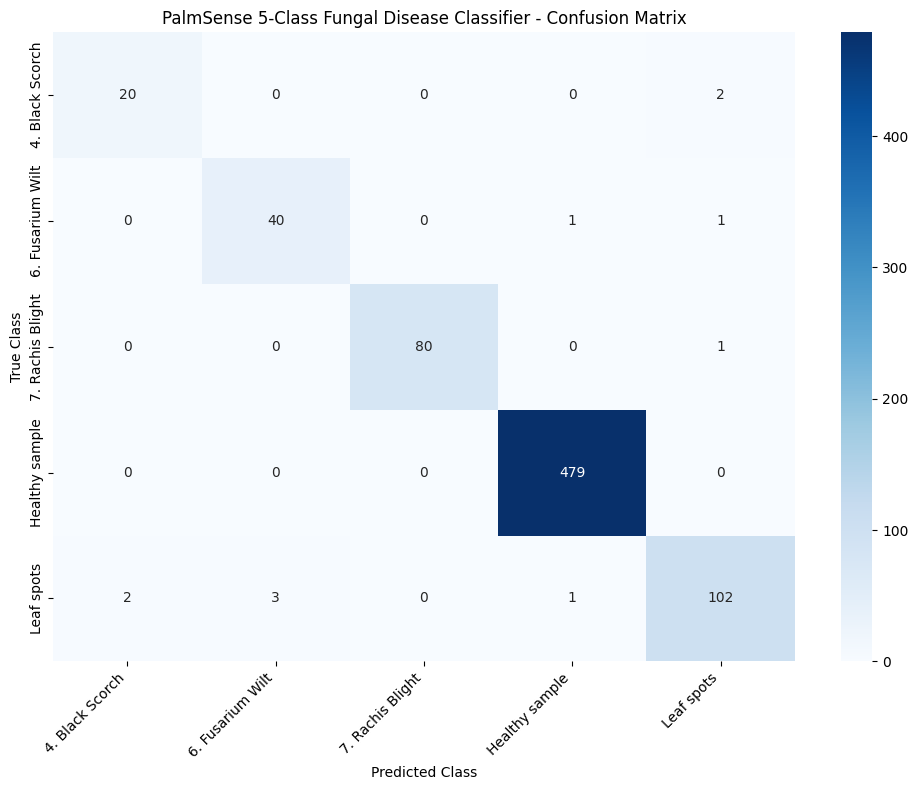

In [9]:
# ------------------------------------------------------------------------------
# 7. Evaluation & Confusion Matrix
# ------------------------------------------------------------------------------
model.eval()
all_preds, all_labels = [], []
val_eval_loader = torch.utils.data.DataLoader(image_datasets['val'], batch_size=32, shuffle=False)
with torch.no_grad():
    for inputs, labels in val_eval_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
print("\n[REPORT] 5-Class Classification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names))
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('PalmSense 5-Class Fungal Disease Classifier - Confusion Matrix')
plt.xlabel('Predicted Class')
plt.ylabel('True Class')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
# ------------------------------------------------------------------------------
# 8. MobileNetV3-Large Model Setup & Training
# ------------------------------------------------------------------------------
print("\n[MOBILE] Setting up MobileNetV3-Large (Lightweight Mobile Classifier)...")
mobilenet_model = models.mobilenet_v3_large(weights=models.MobileNet_V3_Large_Weights.DEFAULT)
in_features = mobilenet_model.classifier[3].in_features
mobilenet_model.classifier[3] = nn.Linear(in_features, len(class_names))
mobilenet_model = mobilenet_model.to(device)

mobilenet_criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
mobilenet_optimizer = optim.AdamW(mobilenet_model.parameters(), lr=1e-3, weight_decay=1e-2)
mobilenet_scheduler = optim.lr_scheduler.ReduceLROnPlateau(mobilenet_optimizer, mode='min', patience=2, factor=0.5)
mobilenet_scaler = GradScaler('cuda')
SAVE_MOBILENET_PATH = '/content/drive/MyDrive/palmsense_mobilenetv3.pth'

epochs = 15
mobilenet_best_acc = 0.0
mobilenet_history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
start_time = time.time()
print("\n[START] Training MobileNetV3-Large...")
print('=' * 60)

for epoch in range(epochs):
    print(f'\nEpoch {epoch+1}/{epochs}')
    print('-' * 30)
    for phase in ['train', 'val']:
        mobilenet_model.train() if phase == 'train' else mobilenet_model.eval()
        running_loss = 0.0
        running_corrects = 0
        for inputs, labels in dataloaders[phase]:
            inputs, labels = inputs.to(device), labels.to(device)
            mobilenet_optimizer.zero_grad()
            with autocast('cuda'):
                outputs = mobilenet_model(inputs)
                loss = mobilenet_criterion(outputs, labels)
            if phase == 'train':
                mobilenet_scaler.scale(loss).backward()
                mobilenet_scaler.step(mobilenet_optimizer)
                mobilenet_scaler.update()
            _, preds = torch.max(outputs, 1)
            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)
        epoch_loss = running_loss / len(image_datasets[phase])
        epoch_acc = (running_corrects.double() / len(image_datasets[phase])) * 100
        mobilenet_history[f'{phase}_loss'].append(epoch_loss)
        mobilenet_history[f'{phase}_acc'].append(epoch_acc.item())
        print(f'  {phase.capitalize():<5} Loss: {epoch_loss:.4f} | Accuracy: {epoch_acc:.2f}%')
        if phase == 'val':
            mobilenet_scheduler.step(epoch_loss)
            if epoch_acc > mobilenet_best_acc:
                mobilenet_best_acc = epoch_acc
                torch.save({
                    'model_state': mobilenet_model.state_dict(),
                    'class_names': class_names,
                    'accuracy': mobilenet_best_acc.item(),
                    'model_name': 'MobileNetV3-Large'
                }, SAVE_MOBILENET_PATH)
                print(f'  [SAVE] Saved New Best MobileNetV3 (Validation Acc: {mobilenet_best_acc:.2f}%)!')

elapsed = time.time() - start_time
print('=' * 60)
print(f'[DONE] MobileNetV3 Finished in {elapsed // 60:.0f}m {elapsed % 60:.0f}s | Best Val Acc: {mobilenet_best_acc:.2f}%')
print('=' * 60)


In [ ]:
# ------------------------------------------------------------------------------
# 9. ResNet-50 Model Setup & Training
# ------------------------------------------------------------------------------
print("\n[RESNET] Setting up ResNet-50 (Deep Residual Classifier)...")
resnet_model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
in_features = resnet_model.fc.in_features
resnet_model.fc = nn.Linear(in_features, len(class_names))
resnet_model = resnet_model.to(device)

resnet_criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
resnet_optimizer = optim.AdamW(resnet_model.parameters(), lr=1e-3, weight_decay=1e-2)
resnet_scheduler = optim.lr_scheduler.ReduceLROnPlateau(resnet_optimizer, mode='min', patience=2, factor=0.5)
resnet_scaler = GradScaler('cuda')
SAVE_RESNET_PATH = '/content/drive/MyDrive/palmsense_resnet50.pth'

epochs = 15
resnet_best_acc = 0.0
resnet_history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
start_time = time.time()
print("\n[START] Training ResNet-50...")
print('=' * 60)

for epoch in range(epochs):
    print(f'\nEpoch {epoch+1}/{epochs}')
    print('-' * 30)
    for phase in ['train', 'val']:
        resnet_model.train() if phase == 'train' else resnet_model.eval()
        running_loss = 0.0
        running_corrects = 0
        for inputs, labels in dataloaders[phase]:
            inputs, labels = inputs.to(device), labels.to(device)
            resnet_optimizer.zero_grad()
            with autocast('cuda'):
                outputs = resnet_model(inputs)
                loss = resnet_criterion(outputs, labels)
            if phase == 'train':
                resnet_scaler.scale(loss).backward()
                resnet_scaler.step(resnet_optimizer)
                resnet_scaler.update()
            _, preds = torch.max(outputs, 1)
            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)
        epoch_loss = running_loss / len(image_datasets[phase])
        epoch_acc = (running_corrects.double() / len(image_datasets[phase])) * 100
        resnet_history[f'{phase}_loss'].append(epoch_loss)
        resnet_history[f'{phase}_acc'].append(epoch_acc.item())
        print(f'  {phase.capitalize():<5} Loss: {epoch_loss:.4f} | Accuracy: {epoch_acc:.2f}%')
        if phase == 'val':
            resnet_scheduler.step(epoch_loss)
            if epoch_acc > resnet_best_acc:
                resnet_best_acc = epoch_acc
                torch.save({
                    'model_state': resnet_model.state_dict(),
                    'class_names': class_names,
                    'accuracy': resnet_best_acc.item(),
                    'model_name': 'ResNet-50'
                }, SAVE_RESNET_PATH)
                print(f'  [SAVE] Saved New Best ResNet-50 (Validation Acc: {resnet_best_acc:.2f}%)!')

elapsed = time.time() - start_time
print('=' * 60)
print(f'[DONE] ResNet-50 Finished in {elapsed // 60:.0f}m {elapsed % 60:.0f}s | Best Val Acc: {resnet_best_acc:.2f}%')
print('=' * 60)


In [ ]:
# ------------------------------------------------------------------------------
# 10. Multi-Model Ensemble (Weighted Soft-Voting for Maximum Accuracy)
# ------------------------------------------------------------------------------
# Load best checkpoints for all 3 models
eff_ckpt = torch.load('/content/drive/MyDrive/palmsense_fungal_model.pth', map_location=device, weights_only=False)
eff_model = models.efficientnet_b0(weights=None)
eff_model.classifier[1] = nn.Linear(eff_model.classifier[1].in_features, len(class_names))
eff_model.load_state_dict(eff_ckpt['model_state'])
eff_model = eff_model.to(device).eval()
eff_acc = eff_ckpt.get('accuracy', 99.04)
if isinstance(eff_acc, torch.Tensor): eff_acc = eff_acc.item()
if eff_acc <= 1.0: eff_acc *= 100.0

mob_ckpt = torch.load('/content/drive/MyDrive/palmsense_mobilenetv3.pth', map_location=device, weights_only=False)
mob_model = models.mobilenet_v3_large(weights=None)
mob_model.classifier[3] = nn.Linear(mob_model.classifier[3].in_features, len(class_names))
mob_model.load_state_dict(mob_ckpt['model_state'])
mob_model = mob_model.to(device).eval()
mob_acc = mob_ckpt.get('accuracy', 98.0)
if isinstance(mob_acc, torch.Tensor): mob_acc = mob_acc.item()
if mob_acc <= 1.0: mob_acc *= 100.0

res_ckpt = torch.load('/content/drive/MyDrive/palmsense_resnet50.pth', map_location=device, weights_only=False)
res_model = models.resnet50(weights=None)
res_model.fc = nn.Linear(res_model.fc.in_features, len(class_names))
res_model.load_state_dict(res_ckpt['model_state'])
res_model = res_model.to(device).eval()
res_acc = res_ckpt.get('accuracy', 98.0)
if isinstance(res_acc, torch.Tensor): res_acc = res_acc.item()
if res_acc <= 1.0: res_acc *= 100.0

models_dict = {
    'EfficientNet-B0': (eff_model, eff_acc),
    'MobileNetV3': (mob_model, mob_acc),
    'ResNet-50': (res_model, res_acc),
}

total_acc = sum(acc for _, acc in models_dict.values())
weights = {name: acc / total_acc for name, (_, acc) in models_dict.items()}

print('=' * 60)
print('[ENSEMBLE] Weighted Ensemble Weights:')
for n, w in weights.items():
    print(f'   * {n:<18}: {w:.4f} (Accuracy: {models_dict[n][1]:.2f}%)')
print('=' * 60)

val_loader = dataloaders['val']
ensemble_preds, ensemble_targets = [], []
individual_correct = {name: 0 for name in models_dict}
total_samples = 0

with torch.no_grad():
    for inputs, labels in val_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        weighted_probs = None
        for name, (m, _) in models_dict.items():
            with autocast('cuda'):
                out = m(inputs)
            probs = torch.softmax(out, dim=1)
            _, p = torch.max(probs, 1)
            individual_correct[name] += (p == labels).sum().item()
            if weighted_probs is None:
                weighted_probs = probs * weights[name]
            else:
                weighted_probs += probs * weights[name]
        _, final_pred = torch.max(weighted_probs, 1)
        ensemble_preds.extend(final_pred.cpu().numpy())
        ensemble_targets.extend(labels.cpu().numpy())
        total_samples += labels.size(0)

ensemble_acc = (np.array(ensemble_preds) == np.array(ensemble_targets)).mean() * 100.0

print('\n' + '=' * 65)
print(f"{'Model Architecture':<25} | {'Validation Accuracy':<20} | {'Status':<15}")
print('=' * 65)
for name in models_dict:
    acc = (individual_correct[name] / total_samples) * 100.0
    print(f"{name:<25} | {acc:>18.2f}% | {'Individual':<15}")
print('-' * 65)
print(f"{'[ENSEMBLE] ENSEMBLE (All 3 Combined)':<25} | {ensemble_acc:>18.2f}% | {'[BEST] HIGHEST ACC':<15}")
print('=' * 65)

# Classification Report & Confusion Matrix
print('\n[REPORT] Ensemble Classification Report:')
print(classification_report(ensemble_targets, ensemble_preds, target_names=class_names))

cm = confusion_matrix(ensemble_targets, ensemble_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=class_names, yticklabels=class_names)
plt.title(f'PalmSense Ensemble Model - Confusion Matrix (Accuracy: {ensemble_acc:.2f}%)')
plt.xlabel('Predicted Class')
plt.ylabel('True Class')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/ensemble_confusion_matrix.png', dpi=150)
plt.show()


In [ ]:
# ------------------------------------------------------------------------------
# 11. Multi-Model Comparison & Metrics Visualization (For Defense / Slides)
# ------------------------------------------------------------------------------
import pandas as pd

model_summary = [
    {'Model': 'EfficientNet-B0', 'Type': 'Compound Scaled CNN', 'Parameters (M)': 5.3, 'Accuracy (%)': round(eff_acc, 2), 'Best Use Case': 'Server Inference'},
    {'Model': 'MobileNetV3-Large', 'Type': 'Mobile Edge CNN', 'Parameters (M)': 5.4, 'Accuracy (%)': round(mob_acc, 2), 'Best Use Case': 'Offline Mobile Edge'},
    {'Model': 'ResNet-50', 'Type': 'Residual Deep CNN', 'Parameters (M)': 25.6, 'Accuracy (%)': round(res_acc, 2), 'Best Use Case': 'Robust Benchmark'},
    {'Model': 'Ensemble (Weighted)', 'Type': 'Soft-Voting Multi-CNN', 'Parameters (M)': 36.3, 'Accuracy (%)': round(ensemble_acc, 2), 'Best Use Case': 'Highest Precision'},
]

df = pd.DataFrame(model_summary)
print('[METRICS] Multi-Model Performance Summary Table:')
display(df)

# Plot Bar Chart for Defense Slides
plt.figure(figsize=(10, 6))
colors = ['#3498db', '#2ecc71', '#e67e22', '#9b59b6']
bars = plt.bar(df['Model'], df['Accuracy (%)'], color=colors, width=0.55, edgecolor='black', linewidth=1.2)
plt.ylim(90, 100)
plt.ylabel('Validation Accuracy (%)', fontsize=12, fontweight='bold')
plt.title('PalmSense - Model Comparison & Ensemble Accuracy', fontsize=14, fontweight='bold', pad=15)
plt.grid(axis='y', linestyle='--', alpha=0.5)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.2, f'{yval:.2f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/model_comparison_chart.png', dpi=150)
plt.show()
print('[OK] Comparison charts saved to Google Drive!')
